<a id="top"></a>
# Estimating Galaxy Cluster Masses with Convolutional Neural Networks

***

## Learning Goals


**In this tutorial, you will see an example of building, compiling, and training a CNN on simulated astronomical data.**  By the end of this tutorial you will have a working example of a simple Convolutional Neural Network (CNN) in Keras.  This CNN can be adapted for any machine learning task that inputs an image and learns a continuous-valued label (regression). 

## Introduction
Convolutional Neural Networks (CNNs) are a class of machine learning (ML) algorithms that can extract information from images.  In this notebook, you will walk through the basic steps of applying a CNN to data:
1. Load the data and visualize a sample of the data
2. Divide the data into training, validation, and testing sets.
3. Build a CNN in Keras
4. Compile the CNN
5. Train the CNN to perform a regression task
6. Evaluate the results.

CNNs can be applied to a wide range of image recognition tasks, and while they are often used for image classification, this notebook builds a CNN for an image regression task.  Here, we will build, compile, and train CNN to estimate galaxy cluster log(masses) from simulated single-band (or _monochromatic_) X-ray images of galaxy clusters.


## Imports
This notebook uses the following:
- *numpy* to handle array functions
- *astropy.io fits* for accessing FITS files
- *matplotlib.pyplot* for plotting data
- *keras* for building the CNN

In [18]:
import numpy as np
print(np.__version__)
print(np.__file__)

2.4.6
/Users/tripathimihir/miniforge3/envs/a3net/lib/python3.11/site-packages/numpy/__init__.py


In [19]:
import os
import sys

print(sys.executable)
print(np.__file__)

/Users/tripathimihir/miniforge3/envs/a3net/bin/python
/Users/tripathimihir/miniforge3/envs/a3net/lib/python3.11/site-packages/numpy/__init__.py


In [20]:
import numpy as np
print("NumPy:", np.__version__)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

import keras
print("Keras:", keras.__version__)

NumPy: 2.4.6
TensorFlow: 2.21.0
Keras: 3.15.1


In [21]:
%matplotlib widget
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from keras import backend as K

***

## CNNs for Regression

### 1. Load the data and visualize a sample of the data

Load the simulated x-ray cluster observations (input images) and cluster log masses (output labels).  These data are described in detail in [Ntampaka et al 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract).  

Briefly, they are 100ks simulated Chandra observations of galaxy clusters in the Illustris TNG simulation.  The images are for a single, large spectral band (0.5-2keV) and are labeled with the cluster masses (log(M500c) in Msolar/h).  The CNN will be used to estimate cluster masses from the simulated cluster images.

#### Load the data

In [22]:
filename = r'/Users/tripathimihir/Documents/a3net_2026/Cluster Mass Hack/cluster_TNG_data.fits'
hdul = fits.open(filename)
image_size = hdul[1].data.shape[1]



#### File Information

Fits is a commonly used data format for astronomical images.  Next, we'll go through some illustritive examples of working with fits files.  Familiarity with fits files is not a requirement for this tutorial, but we refer you to the [Astropy Documentation](https://docs.astropy.org/en/stable/io/fits/index.html) if you want further information about this file format.

In [23]:
# Metadata about this observation is available in the header
display(hdul[0].header)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
SIMULATD= 'T       '                                                            
HLSPVER = '0       '                                                            
HLSPID  = 'XXXX    '                                                            
DOI     = 'XXXX    '                                                            
INSTRUME= 'ACIS-I  '                                                            
LICENSE = 'CC BY 4.0'                                                           
LICENURL= 'https://creativecommons.org/licenses/by/4.0/'                        
OBSERVAT= 'Chandra '                                                            
XPOSURE = '100ks   '        

In [24]:
# information about the data in the second HDU
display(hdul[1].header)

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  140                                                  
NAXIS2  =                  140                                                  
NAXIS3  =                  986                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               

In [25]:
#information about the data in the third HDU
display(hdul[2].header)

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   15 / length of dimension 1                          
NAXIS2  =                  986 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    7 / number of table fields                         
TTYPE1  = 'log_M500'                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'cluster_id'                                                          
TFORM2  = 'I       '                                                            
TTYPE3  = 'view_los'        

In [26]:
# The image data is stored in the second HDU (Header/Data Unit)

# Let's check the table in third hdu to see what information is available for each cluster
# It is an astropy table so let's convert it to a pandas dataframe for easier viewing of the data
data_table = hdul[2].data

data_table




FITS_rec([(15.062608 ,   0, 'y', 0, 1, 0, 0),
          (15.062608 ,   0, 'z', 0, 1, 0, 0),
          (14.984198 ,   1, 'x', 1, 1, 0, 0),
          (14.984198 ,   1, 'y', 1, 1, 0, 0),
          (14.984198 ,   1, 'z', 1, 1, 0, 0),
          (14.847251 ,   2, 'x', 2, 1, 0, 0),
          (14.847251 ,   2, 'y', 2, 1, 0, 0),
          (14.847251 ,   2, 'z', 2, 1, 0, 0),
          (14.80014  ,   3, 'x', 3, 1, 0, 0),
          (14.80014  ,   3, 'y', 3, 1, 0, 0),
          (14.80014  ,   3, 'z', 3, 1, 0, 0),
          (14.777473 ,   4, 'x', 4, 1, 0, 0),
          (14.777473 ,   4, 'y', 4, 1, 0, 0),
          (14.777473 ,   4, 'z', 4, 1, 0, 0),
          (14.592947 ,   5, 'x', 5, 1, 0, 0),
          (14.592947 ,   5, 'y', 5, 1, 0, 0),
          (14.592947 ,   5, 'z', 5, 1, 0, 0),
          (14.481517 ,   6, 'x', 6, 1, 0, 0),
          (14.481517 ,   6, 'y', 6, 1, 0, 0),
          (14.481517 ,   6, 'z', 6, 1, 0, 0),
          (14.577853 ,   7, 'x', 7, 1, 0, 0),
          (14.577853 ,   7, 'y', 7

/var/folders/n8/c77nkvtx26962lj0xqpghf540000gn/T/ipykernel_5558/1284549622.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(hdul[1].data[n]), vmin=0, vmax=2.7)


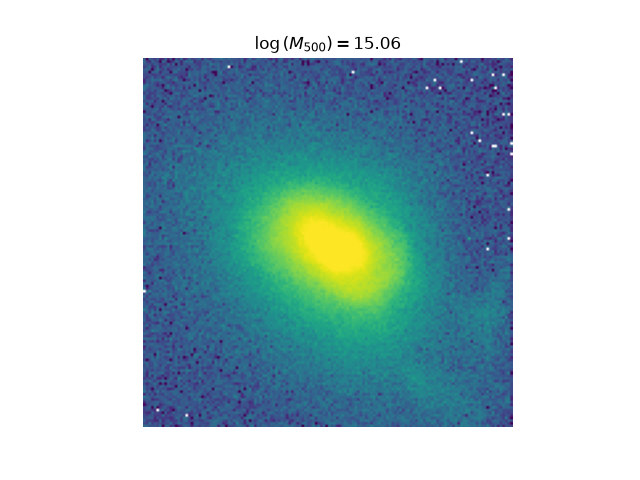

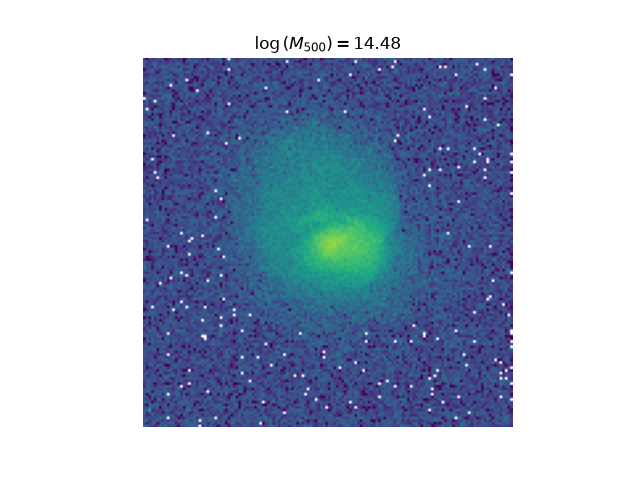

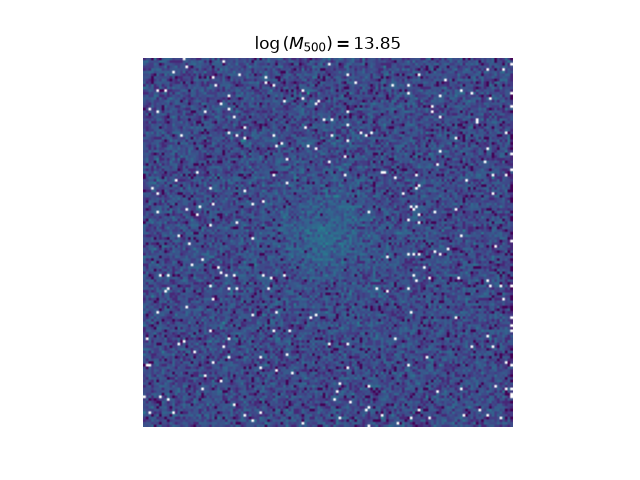

In [27]:
# We can plot a few sample images and label them with their masses

image_size = hdul[1].data.shape[1]

for n in [0, 100, 900]:
    plt.figure()
    #plot the image
    plt.imshow(np.log10(hdul[1].data[n]), vmin=0, vmax=2.7)
    plt.axis('off')
    plt.title(r'$\log\left(M_\mathrm{500}\right)=$'+'{:.2f}'.format(hdul[2].data['log_M500'][n]))

#### Comments on the sample images
As you can see above, there are some pixels with no photons (they are displayed as white squares).  It's also interesting to note that the images vary significantly in total luminosity; the figures above show the log of the number of photons, and even so, the lowest-mass cluster is barely visible and the highest-mass cluster is saturated at the core for this colormap.


### 2. Divide the data into training, validation, and testing sets.

There are a number of tools for dividing a data set into training, validation, and testing data, such as Scikit-Learn's [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  For this work, the author has divided the data into folds and has provided a recommendation for how to divide these into training, validation, and testing sets.

We will denote the input images as "X" and the output labels as "Y".

Note that we are reshaping the image array as follows:  (number_of_images, image_width, image_length, 1) 
This is referred to as a "channels last" approach, where the final axis denotes the number of "colors" or "channels".  Our monochromatic image only has a single channel, while RGB images have three.  CNN's will work with an arbitrary number of channels.



In [28]:
train_ind = np.argwhere(hdul[2].data['train'] == 1)
train_X = hdul[1].data[train_ind].reshape(-1, image_size, image_size, 1)
train_Y = hdul[2].data['log_M500'][train_ind]

val_ind = np.argwhere(hdul[2].data['validate'] == 1)
val_X = hdul[1].data[val_ind].reshape(-1, image_size, image_size, 1)
val_Y = hdul[2].data['log_M500'][val_ind]

test_ind = np.argwhere(hdul[2].data['test'] == 1)
test_X = hdul[1].data[test_ind].reshape(-1, image_size, image_size, 1)
test_Y = hdul[2].data['log_M500'][test_ind]

ML models often converge faster when the output is _roughly_ between 0 and 1. Next, let's perform a normalization that will speed up the training process a bit -- calculate the minimum log(mass) and subtract it from the Y labels as a change of units.  We'll put it back, later in the notebook, just before we plot the results.  

We can simply subtract off a constant value because our output doesn't have a large dynamical range, but there may be cases where you want to handle this more carefully and force all of your labels to be strictly in the (0,1) interval.  

In [29]:
table_hdu = hdul[2]
if table_hdu.data is None:
	raise ValueError("The third HDU does not contain table data.")

norm = np.nanmin(table_hdu.data['log_M500'])
train_Y -= norm
val_Y -= norm
test_Y -= norm

### 3. Build a CNN in Keras

Here, we will build the model described in Section 2.2 of [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract)

Further details about Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, and Dense layers can be found in the [Keras Layers Documentation](https://keras.io/api/layers/).  Further details about the relu activation function can be found in the [Keras Activation Function Documentation](https://keras.io/api/layers/activations/).

In [30]:
input_shape = (image_size, image_size, 1)
model = Sequential()
model.add(Conv2D(16, kernel_size=(3, 3), input_shape=input_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.1))
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='linear'))

### 4. Compile the CNN

Next, we compile the model.  As in [Ntampaka et al., 2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...876...82N/abstract), we select the Adam opmimizer (with a learning rate that is slightly decreased from the default rate) and the mean squared error loss function.

You can learn more about [optimizers](https://keras.io/api/optimizers/) and more about [loss functions for regression tasks](https://keras.io/api/losses/) in the [Keras documentation](https://keras.io/)

In [31]:
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

### 5. Train the CNN to perform a regression task

We will start with training for 5 epochs, but this almost certainly won't be long enough to get great results.  Once you've run your model and evaluated the fit, you can come back here and run the next cell again for 100 epochs or longer.  

You can learn more about model.fit [here](https://keras.rstudio.com/reference/fit.html)

In [32]:
epochs = 5
batch_size = 16 #lower this value if you get a memory error
hist = model.fit(train_X, train_Y, batch_size=batch_size, verbose=True,  epochs=epochs)

Epoch 1/5


error: operand #1 does not dominate this use
E0000 00:00:1787798677.041890   68082 meta_optimizer.cc:967] tfg_optimizer{any(tfg-consolidate-attrs,tfg-toposort,tfg-shape-inference{graph-version=0},tfg-prepare-attrs-export)} failed: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
W0000 00:00:1787798677.042119   68082 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 
error: operand #0 does not dominate this use
W0000 00:00:1787798677.203449   68082 optimize_function_graph_utils.cc:634] Ignoring multi-device function optimization failure: INVALID_ARGUMENT: MLIR Graph Optimizer failed: 


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.3340
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1689
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1833
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2523
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1586


### 6. Evaluate the results

Next, we will plot up the true and predicted log(masses).  We have only trained for 5 epochs, so we expect noisy results and catastrophic outliers.  Don't panic -- we will discuss how to fix this in the FAQs. 

In [33]:
prediction = model.predict(test_X, verbose=0, batch_size=batch_size).flatten()for name in table.names:
    arr = np.array(table[name])
# Remember when we subtracted off the min in an earlier cell?  In the next line, we're putting it back in!
plt.scatter(test_Y + norm, prediction + norm, c='C0', label='model predictions')
x = np.linspace(np.min(test_Y+norm), np.max(test_Y+norm), 100)
plt.plot(x,x,ls='--', c='C1', label='one-to-one line')
plt.xlabel('True '+r'$\log\left(M_{500c}\right)$')
plt.ylabel('Predicted '+r'$\log\left(M_{500c}\right)$')
plt.title('Results after {:.0f} epochs'.format(epochs))
plt.show()


SyntaxError: invalid syntax (177629852.py, line 1)

## FAQs

- **These results don't look so great.  What happened?** We only trained for 5 epochs, which likely produced some outlying, biased, and/or noisy results.  Go back to Section 4 ("Train the CNN to perform a regression task") and increase the number of epochs to 100 and train again.  Does your model perform better?  Your results may look better/worse/different from this due to the stochastic nature of training.
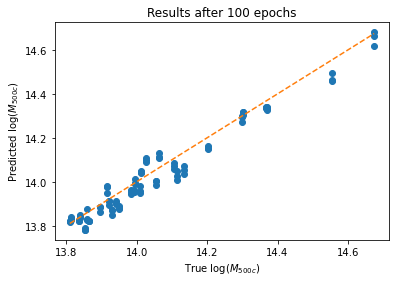


- **How did my model's loss improve with time?** Try plotting epochs `np.arange(epochs)` vs. loss `hist.history['loss']` to see how your model's loss decreased with time.  You should be aware:  when you start training again, you pick up where your model left off.  If you want to "reset" your model to epoch 0 and random weights, you should run the cells to make and compile the model again.


- **Why didn't we use the validation data?** The validation data isn't used in this tutorial, but it's available if you'd like to explore methods for preventing overfitting.  Try passing the validation data to your model fit like this `hist = model.fit(train_X, train_Y, validation_data = (val_X, val_Y), batch_size=batch_size, verbose=True, epochs=epochs)` .  While this training scheme will never use your validation data for improving the model, it will return validation loss.  So, now you can also plot `np.arange(epochs)` vs. loss `hist.history['val_loss']` to see how your validation loss decreases with time.  Validation loss can be a useful tool in identifying whether a model has [overfit](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).


- **Can I try a different model?  I think the results could be improved.** Yes!  You can try adding layers, swapping out the max pooling for average pooling, changing the activation functions, swapping out the loss function, or trying a different optimizer or learning rate.  Experiment and see what model changes give the best results.


- **I want to test my model on my training data!** No. You will convince yourself that your results are much better than they actually are.  Always keep your training, validation, and testing sets completely separate!

## About this Notebook

**Author:** Michelle Ntampaka, Data Scientist, mntampaka@stsci.edu
**Updated On:** 2021-10-01

## Citations

If you use this data set, `astropy`, or `keras` for published research, please cite the
authors. Follow these links for more information:

* [Citing the data set](??)
* [Citing `astropy`](https://www.astropy.org/acknowledging.html)
* [Citing `keras`](https://keras.io/getting_started/faq/#how-should-i-cite-keras)



In [138]:
print(hdul)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001C42F51F6D0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x000001C42E5E3410>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001C48B7B9490>]


In [139]:
print(hdul[2].columns)

ColDefs(
    name = 'log_M500'; format = 'E'
    name = 'cluster_id'; format = 'I'
    name = 'view_los'; format = 'A'
    name = 'fold'; format = 'I'
    name = 'train'; format = 'I'
    name = 'validate'; format = 'I'
    name = 'test'; format = 'I'
)


In [140]:
print(hdul[2].data.names)

['log_M500', 'cluster_id', 'view_los', 'fold', 'train', 'validate', 'test']


In [141]:
for name in hdul[2].data.names:
    print(name)

log_M500
cluster_id
view_los
fold
train
validate
test


In [17]:
data = {}

table = hdul[2].data

for name in table.names:
    arr = np.array(table[name])

    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.astype(arr.dtype.newbyteorder('='))

    data[name] = arr

df = pd.DataFrame(data)

In [143]:
df


,log_M500,cluster_id,view_los,fold,train,validate,test
0,15.062608,0,y,0,1,0,0
1,15.062608,0,z,0,1,0,0
2,14.984198,1,x,1,1,0,0
3,14.984198,1,y,1,1,0,0
4,14.984198,1,z,1,1,0,0
...,...,...,...,...,...,...,...
981,13.748425,383,y,3,1,0,0
982,13.748425,383,z,3,1,0,0
983,13.814128,388,x,8,0,1,0
984,13.814128,388,y,8,0,1,0


In [144]:
# Find clusters that don't have exactly 3 projections

projection_counts = (
    df.groupby("cluster_id")["view_los"]
      .nunique()
)

print(projection_counts.value_counts())

print("\nClusters with missing projections:")
print(
    df.loc[
        df["cluster_id"].isin(
            projection_counts[projection_counts != 3].index
        ),
        ["cluster_id", "log_M500", "view_los", "fold",
         "train", "validate", "test"]
    ].sort_values("cluster_id").to_string(index=False)
)

view_los
3    328
2      1
Name: count, dtype: int64

Clusters with missing projections:
 cluster_id  log_M500 view_los  fold  train  validate  test
          0 15.062608        y     0      1         0     0
          0 15.062608        z     0      1         0     0


In [145]:
# Check projection completeness per cluster

projection_counts = (
    df.groupby("cluster_id")["view_los"]
      .nunique()
      .value_counts()
      .sort_index()
)

print("Number of clusters by number of projections:")
print(projection_counts)

print("\nClusters that do NOT have exactly 3 projections:")

bad_clusters = (
    df.groupby("cluster_id")
      .filter(lambda g: g["view_los"].nunique() != 3)
      .sort_values(["cluster_id", "view_los"])
)

display(bad_clusters)

Number of clusters by number of projections:
view_los
2      1
3    328
Name: count, dtype: int64

Clusters that do NOT have exactly 3 projections:


,log_M500,cluster_id,view_los,fold,train,validate,test
0,15.062608,0,y,0,1,0,0
1,15.062608,0,z,0,1,0,0


In [146]:
for i, hdu in enumerate(hdul):
    print("\nHDU", i)
    print("Type:", type(hdu).__name__)
    print("Shape:", getattr(hdu.data, "shape", None))
    print("Dtype:", getattr(hdu.data, "dtype", None))


HDU 0
Type: PrimaryHDU
Shape: None
Dtype: None

HDU 1
Type: ImageHDU
Shape: (986, 140, 140)
Dtype: >f4

HDU 2
Type: BinTableHDU
Shape: (986,)
Dtype: (numpy.record, [('log_M500', '>f4'), ('cluster_id', '>i2'), ('view_los', 'S1'), ('fold', '>i2'), ('train', '>i2'), ('validate', '>i2'), ('test', '>i2')])


In [147]:
print(f"Number of images: {images.shape[0]}")
print(f"Number of DataFrame rows: {len(df)}")
# Both should be 986.

Number of images: 986
Number of DataFrame rows: 986


In [148]:
cluster_id = 0
idx = df[df['cluster_id'] == cluster_id].index
print(f"Indices for cluster {cluster_id}: {idx.values}")
print(f"Projections: {df.loc[idx, 'view_los'].values}")

Indices for cluster 0: [0 1]
Projections: ['y' 'z']


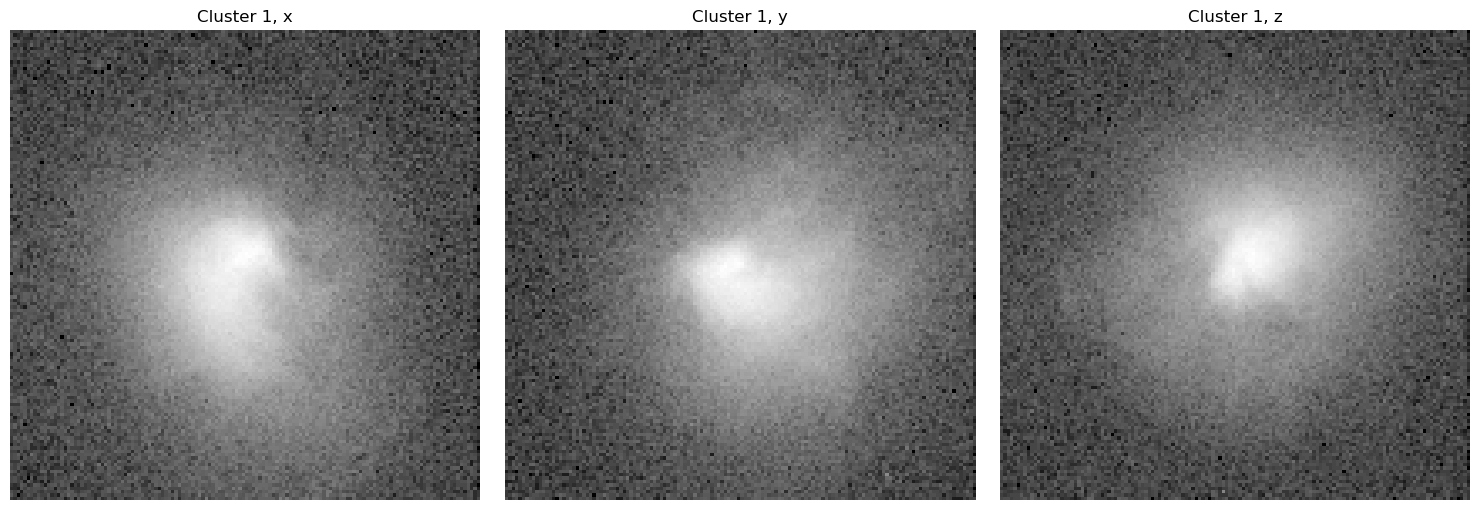

In [149]:
cluster_id = 1
idx = df[df['cluster_id'] == cluster_id].index
n = len(idx)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]
for ax, i in zip(axes, idx):
    ax.imshow(np.log10(images[i] + 1), cmap='gray')
    ax.set_title(f"Cluster {cluster_id}, {df.loc[i, 'view_los']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [150]:
cluster_summary = df.groupby('cluster_id').agg(
    n_images=('view_los', 'count'),
    projections=('view_los', lambda x: list(x)),
    logM=('log_M500', 'first')
).reset_index()
print(cluster_summary.head())

   cluster_id  n_images projections       logM
0           0         2      [y, z]  15.062608
1           1         3   [x, y, z]  14.984198
2           2         3   [x, y, z]  14.847251
3           3         3   [x, y, z]  14.800140
4           4         3   [x, y, z]  14.777473


In [151]:
cluster_to_indices = {
    cid: df[df['cluster_id'] == cid].index.values
    for cid in df['cluster_id'].unique()
}
# Example: images for cluster 5
print(cluster_to_indices.get(5))

[14 15 16]


In [152]:
# For each cluster, see which split each projection belongs to
split_counts = df.groupby('cluster_id')[['train', 'validate', 'test']].sum()
# Show clusters that have projections in multiple splits
print(split_counts[(split_counts.sum(axis=1) > 1) & (split_counts.sum(axis=1) < 3)])

            train  validate  test
cluster_id                       
0               2         0     0


In [153]:
print(cluster_to_indices)

{np.int16(0): array([0, 1]), np.int16(1): array([2, 3, 4]), np.int16(2): array([5, 6, 7]), np.int16(3): array([ 8,  9, 10]), np.int16(4): array([11, 12, 13]), np.int16(5): array([14, 15, 16]), np.int16(6): array([17, 18, 19]), np.int16(7): array([20, 21, 22]), np.int16(8): array([23, 24, 25]), np.int16(9): array([26, 27, 28]), np.int16(10): array([29, 30, 31]), np.int16(11): array([32, 33, 34]), np.int16(12): array([35, 36, 37]), np.int16(13): array([38, 39, 40]), np.int16(14): array([41, 42, 43]), np.int16(15): array([44, 45, 46]), np.int16(16): array([47, 48, 49]), np.int16(17): array([50, 51, 52]), np.int16(18): array([53, 54, 55]), np.int16(19): array([56, 57, 58]), np.int16(20): array([59, 60, 61]), np.int16(21): array([62, 63, 64]), np.int16(22): array([65, 66, 67]), np.int16(23): array([68, 69, 70]), np.int16(24): array([71, 72, 73]), np.int16(25): array([74, 75, 76]), np.int16(26): array([77, 78, 79]), np.int16(27): array([80, 81, 82]), np.int16(28): array([83, 84, 85]), np.int

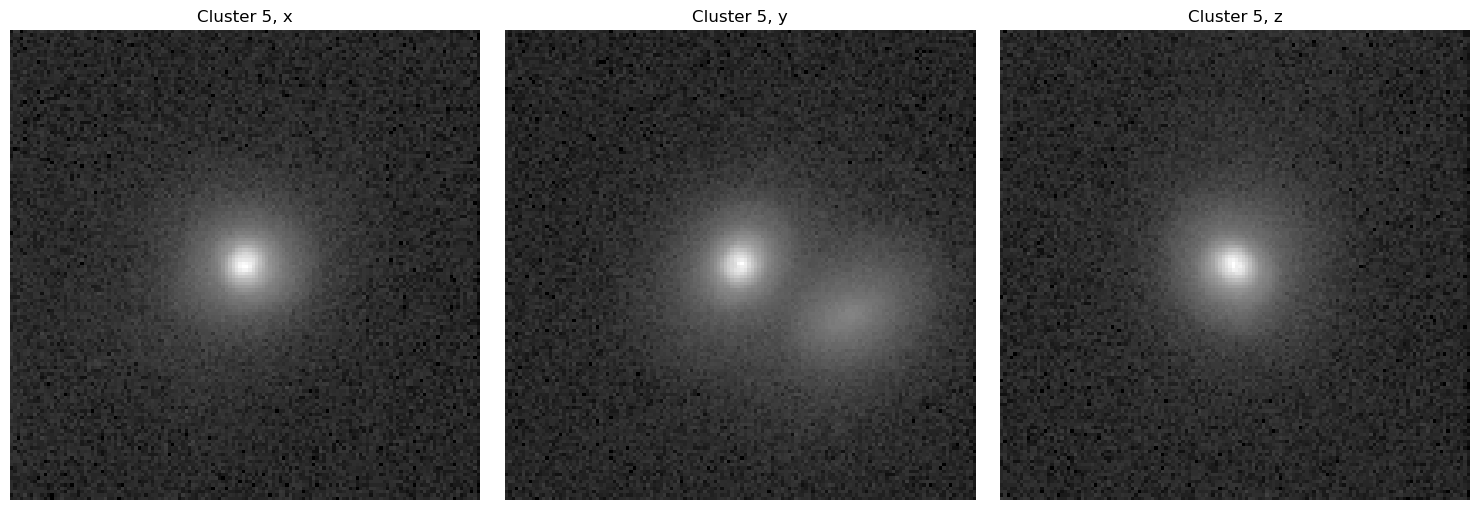

In [154]:
cluster_id = 5
indices = cluster_to_indices[cluster_id]   # e.g., [14,15,16]
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, idx in zip(axes, indices):
    ax.imshow(np.log10(images[idx] + 1), cmap='gray')
    ax.set_title(f"Cluster {cluster_id}, {df.loc[idx, 'view_los']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [155]:
cluster_id = 10
indices = cluster_to_indices[cluster_id]
masses = df.loc[indices, 'log_M500'].values
print(f"Cluster {cluster_id} masses: {masses}")

Cluster 10 masses: [14.655585 14.655585 14.655585]


In [156]:
import numpy as np

cluster_avg_images = {}
for cid, idxs in cluster_to_indices.items():
    cluster_avg_images[cid] = np.mean(images[idxs], axis=0)  # average over projections

In [157]:
all_ids = set(range(0, 389))   # assuming max ID is 388
present_ids = set(cluster_to_indices.keys())
missing_ids = sorted(all_ids - present_ids)
print("Missing cluster IDs:", missing_ids)

Missing cluster IDs: [123, 150, 208, 219, 237, 238, 246, 250, 264, 269, 273, 289, 290, 294, 296, 297, 301, 303, 304, 310, 311, 316, 318, 321, 322, 325, 330, 331, 335, 338, 339, 342, 346, 347, 349, 350, 351, 352, 358, 359, 360, 361, 364, 366, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 381, 382, 384, 385, 386, 387]


In [158]:
test_clusters = df.loc[test_ind.flatten(), 'cluster_id'].values
predicted_masses = model.predict(test_X).flatten() + norm
true_masses = test_Y.flatten() + norm
# Now you can group by cluster and see per‑cluster performance

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [159]:
import pickle
with open('cluster_to_indices.pkl', 'wb') as f:
    pickle.dump(cluster_to_indices, f)

In [160]:
# Rebuild the model (same architecture)
model = Sequential()
model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(140, 140, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.1))
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compile again
model.compile(loss='mean_squared_error',
              optimizer=keras.optimizers.Adam(learning_rate=0.0002))

C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [161]:
epochs = 150
batch_size = 16

hist = model.fit(
    train_X, train_Y,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(val_X, val_Y),
    verbose=1
)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.4598 - val_loss: 0.0423
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1271 - val_loss: 0.0227
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.2473 - val_loss: 0.0206
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.2212 - val_loss: 0.0245
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0992 - val_loss: 0.0233
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0570 - val_loss: 0.0249
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0832 - val_loss: 0.0363
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0586 - val_loss: 0.0258
Epoch 9/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0477 - val_loss: 0.0242
Epoch 10/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1001 - val_loss: 0.0173
Epoch 11/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0967 - val_loss: 0.0340
Epoch 12/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

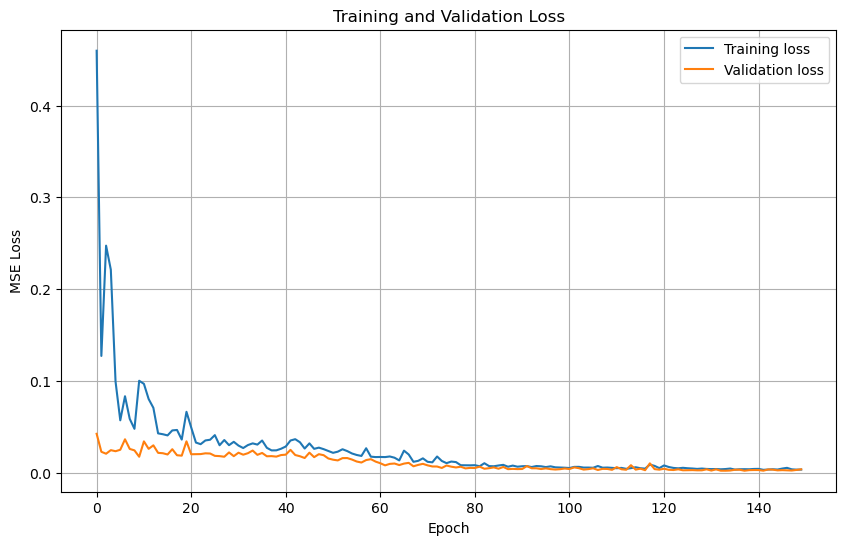

In [162]:
plt.figure(figsize=(10,6))
plt.plot(hist.epoch, hist.history['loss'], label='Training loss')
plt.plot(hist.epoch, hist.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


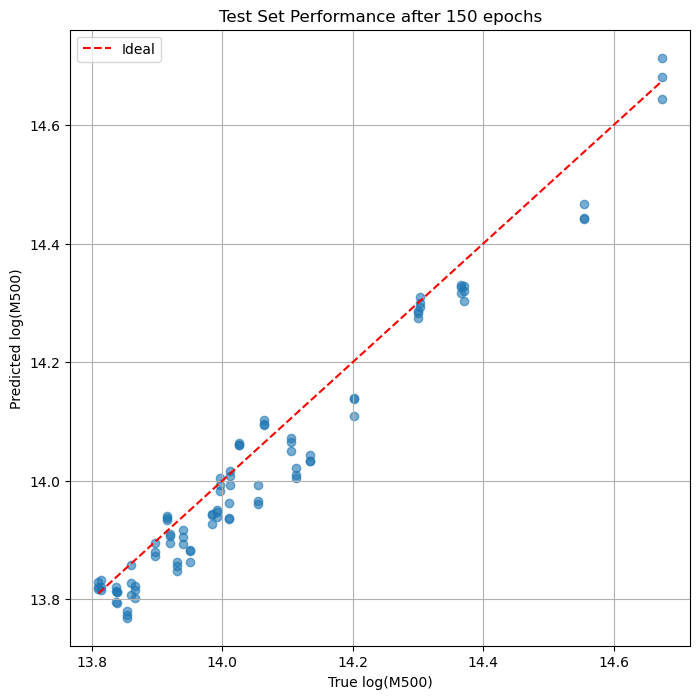

In [163]:
predictions = model.predict(test_X, batch_size=batch_size).flatten()
true_values = test_Y.flatten() + norm   # revert normalization
predicted_values = predictions + norm

# Scatter plot
plt.figure(figsize=(8,8))
plt.scatter(true_values, predicted_values, alpha=0.6)
plt.plot([true_values.min(), true_values.max()],
         [true_values.min(), true_values.max()], 'r--', label='Ideal')
plt.xlabel('True log(M500)')
plt.ylabel('Predicted log(M500)')
plt.title(f'Test Set Performance after {epochs} epochs')
plt.legend()
plt.grid(True)
plt.show()

In [164]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(true_values, predicted_values)
mae = mean_absolute_error(true_values, predicted_values)
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))

print(f"R² score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R² score: 0.9378
MAE: 0.0441
RMSE: 0.0536


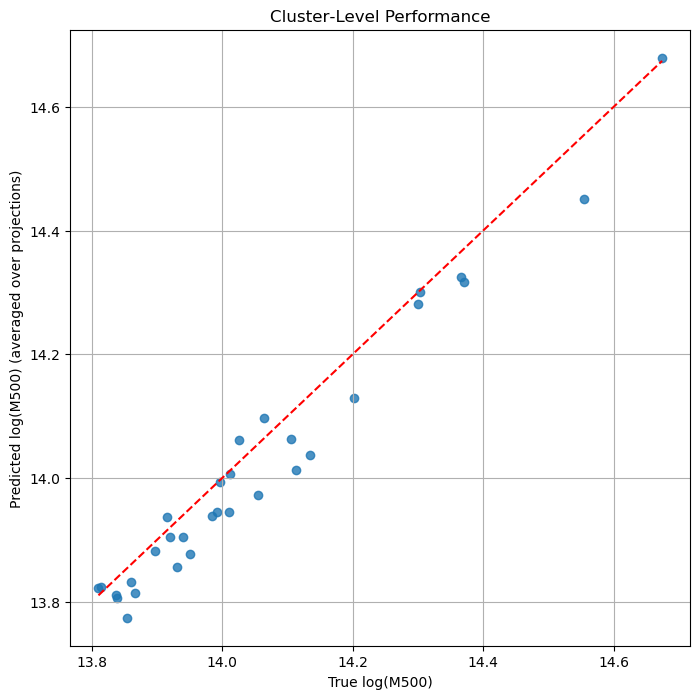

Cluster‑level R²: 0.9400
Cluster‑level MAE: 0.0431
Cluster‑level RMSE: 0.0526


In [165]:
# Get test indices and their clusters
test_indices = test_ind.flatten()
test_cluster_ids = df.loc[test_indices, 'cluster_id'].values

# Create a dictionary to store predictions per cluster
cluster_preds = {}
cluster_trues = {}

for cid in np.unique(test_cluster_ids):
    # Get indices of test images belonging to this cluster
    mask = (test_cluster_ids == cid)
    idxs = test_indices[mask]
    # True mass (same for all projections)
    true_mass = true_values[mask][0]
    # Predicted masses for these projections
    pred_masses = predicted_values[mask]
    # Store average prediction per cluster
    cluster_preds[cid] = np.mean(pred_masses)
    cluster_trues[cid] = true_mass

# Convert to arrays for plotting
clust_true = np.array([cluster_trues[cid] for cid in cluster_trues])
clust_pred = np.array([cluster_preds[cid] for cid in cluster_trues])

# Scatter plot at cluster level
plt.figure(figsize=(8,8))
plt.scatter(clust_true, clust_pred, alpha=0.8)
plt.plot([clust_true.min(), clust_true.max()],
         [clust_true.min(), clust_true.max()], 'r--')
plt.xlabel('True log(M500)')
plt.ylabel('Predicted log(M500) (averaged over projections)')
plt.title('Cluster‑Level Performance')
plt.grid(True)
plt.show()

# Cluster‑level metrics
clust_r2 = r2_score(clust_true, clust_pred)
clust_mae = mean_absolute_error(clust_true, clust_pred)
clust_rmse = np.sqrt(mean_squared_error(clust_true, clust_pred))

print(f"Cluster‑level R²: {clust_r2:.4f}")
print(f"Cluster‑level MAE: {clust_mae:.4f}")
print(f"Cluster‑level RMSE: {clust_rmse:.4f}")

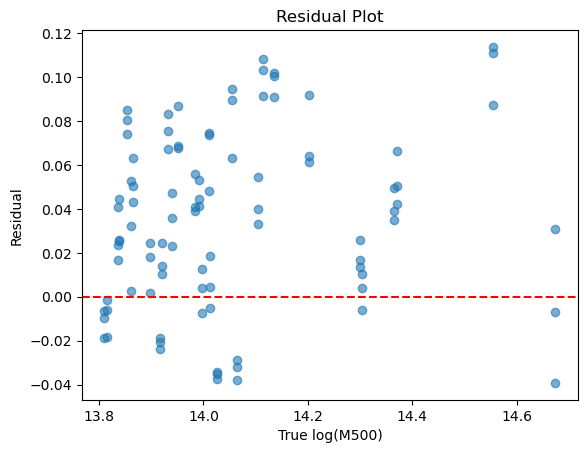

In [166]:
residuals = true_values - predicted_values
plt.scatter(true_values, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True log(M500)')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

In [167]:
# Use existing df and images
# Exclude cluster 0 (incomplete)
clusters = df['cluster_id'].unique()
clusters = clusters[clusters != 0]
print(f"Using {len(clusters)} clusters for CV (excluding cluster 0)")

# Build a dictionary mapping cluster_id -> list of image indices (already have cluster_to_indices)
# But we need to exclude cluster 0 from it
cluster_indices = {cid: cluster_to_indices[cid] for cid in clusters}

# For each cluster, get its mass (same for all projections)
cluster_masses = {cid: df[df['cluster_id'] == cid]['log_M500'].values[0] for cid in clusters}

# Normalize masses (subtract global minimum)
norm = np.nanmin(df['log_M500'])
for cid in cluster_masses:
    cluster_masses[cid] -= norm

Using 328 clusters for CV (excluding cluster 0)


In [168]:
# Group by cluster and count splits (each cluster may have 2 or 3 rows)
split_counts = df.groupby('cluster_id')[['train', 'validate', 'test']].sum()

n_train = (split_counts['train'] > 0).sum()
n_val   = (split_counts['validate'] > 0).sum()
n_test  = (split_counts['test'] > 0).sum()

train_masses = df[df['train'] == 1]['log_M500'].unique()
val_masses   = df[df['validate'] == 1]['log_M500'].unique()
test_masses  = df[df['test'] == 1]['log_M500'].unique()

print("=== Dataset Split Summary ===")
print(f"Training clusters: {n_train}   (mass range: {train_masses.min():.2f} – {train_masses.max():.2f})")
print(f"Validation clusters: {n_val}   (mass range: {val_masses.min():.2f} – {val_masses.max():.2f})")
print(f"Test clusters: {n_test}        (mass range: {test_masses.min():.2f} – {test_masses.max():.2f})")

=== Dataset Split Summary ===
Training clusters: 265   (mass range: 13.57 – 15.06)
Validation clusters: 33   (mass range: 13.78 – 14.55)
Test clusters: 31        (mass range: 13.81 – 14.67)


In [169]:
def show_cluster(cid):
    idxs = cluster_to_indices.get(cid)
    if idxs is None:
        print(f"Cluster {cid} not found.")
        return
    projs = df.loc[idxs, 'view_los'].values
    print(f"Cluster {cid}: indices {idxs}, projections {projs}")

# Example
show_cluster(5)

Cluster 5: indices [14 15 16], projections ['x' 'y' 'z']


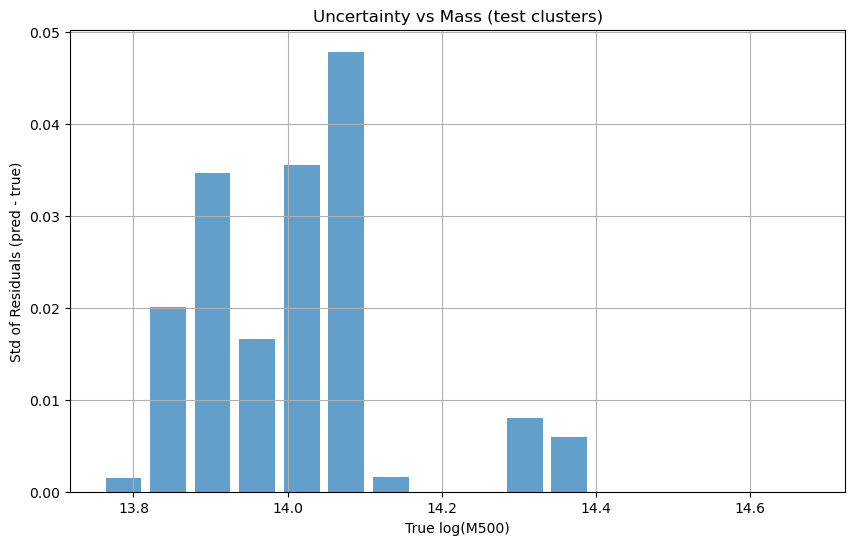

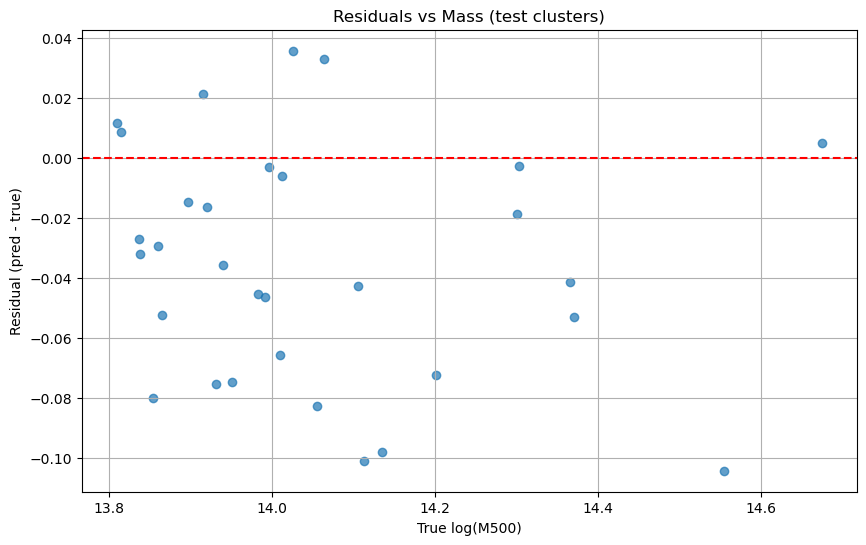

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# Use your existing test set cluster‑averaged predictions
test_indices = test_ind.flatten()
test_cluster_ids = df.loc[test_indices, 'cluster_id'].values

cluster_true = {}
cluster_pred = {}
for cid in np.unique(test_cluster_ids):
    mask = (test_cluster_ids == cid)
    idxs = test_indices[mask]
    cluster_true[cid] = true_values[mask][0]
    cluster_pred[cid] = np.mean(predicted_values[mask])

true_mass_clust = np.array([cluster_true[c] for c in cluster_true])
pred_mass_clust = np.array([cluster_pred[c] for c in cluster_true])
residuals = pred_mass_clust - true_mass_clust

# Define bins covering the test mass range
bins = np.linspace(13.7, 14.8, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_indices = np.digitize(true_mass_clust, bins)

# Compute std of residuals per bin
bin_std = []
for i in range(len(bins)-1):
    mask = bin_indices == i+1
    if np.sum(mask) > 0:
        bin_std.append(np.std(residuals[mask]))
    else:
        bin_std.append(np.nan)

# Plot
plt.figure(figsize=(10,6))
plt.bar(bin_centers, bin_std, width=(bins[1]-bins[0])*0.8, alpha=0.7)
plt.xlabel('True log(M500)')
plt.ylabel('Std of Residuals (pred - true)')
plt.title('Uncertainty vs Mass (test clusters)')
plt.grid(True)
plt.show()

# Also scatter residuals vs mass
plt.figure(figsize=(10,6))
plt.scatter(true_mass_clust, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True log(M500)')
plt.ylabel('Residual (pred - true)')
plt.title('Residuals vs Mass (test clusters)')
plt.grid(True)
plt.show()

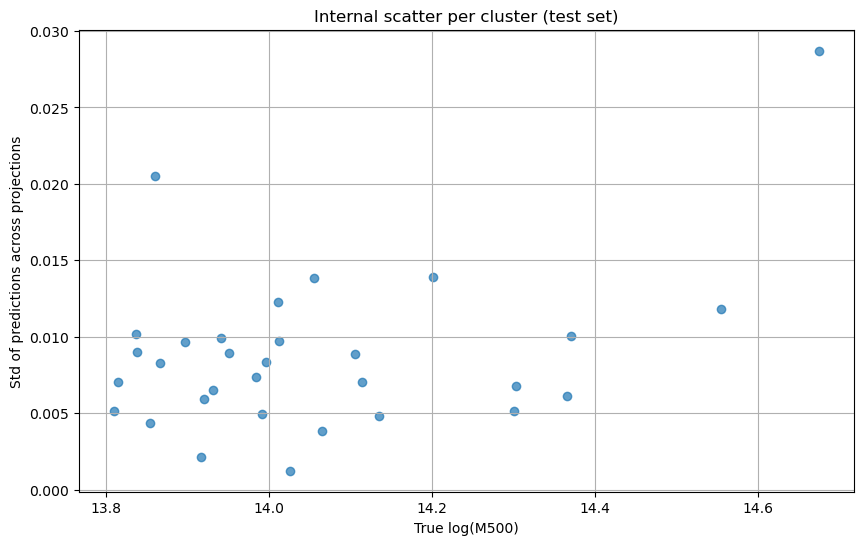

In [171]:
# For each test cluster, get the predictions for each projection
cluster_scatter = {}
for cid in np.unique(test_cluster_ids):
    mask = (test_cluster_ids == cid)
    preds_for_cluster = predicted_values[mask]   # predictions for its projections
    cluster_scatter[cid] = np.std(preds_for_cluster)

# Convert to arrays for plotting
scatter_vals = np.array([cluster_scatter[c] for c in cluster_scatter])
true_masses_scatter = np.array([cluster_true[c] for c in cluster_scatter])

plt.figure(figsize=(10,6))
plt.scatter(true_masses_scatter, scatter_vals, alpha=0.7)
plt.xlabel('True log(M500)')
plt.ylabel('Std of predictions across projections')
plt.title('Internal scatter per cluster (test set)')
plt.grid(True)
plt.show()

***

In [172]:
# After the evaluation where you computed:
# predictions = model.predict(test_X, ...).flatten()
# true_values = test_Y.flatten() + norm
# predicted_values = predictions + norm

# Compute residuals
residuals = true_values - predicted_values   # or predicted - true, same std

scatter = np.std(residuals)
bias = np.mean(residuals)

print("="*50)
print("CORRECT SCATTER (from trained model)")
print("="*50)
print(f"Scatter (std of residuals): {scatter:.4f} dex")
print(f"Mass scatter: {100*(10**scatter - 1):.1f}%")
print(f"Bias: {bias:.4f} dex")

CORRECT SCATTER (from trained model)
Scatter (std of residuals): 0.0400 dex
Mass scatter: 9.7%
Bias: 0.0356 dex


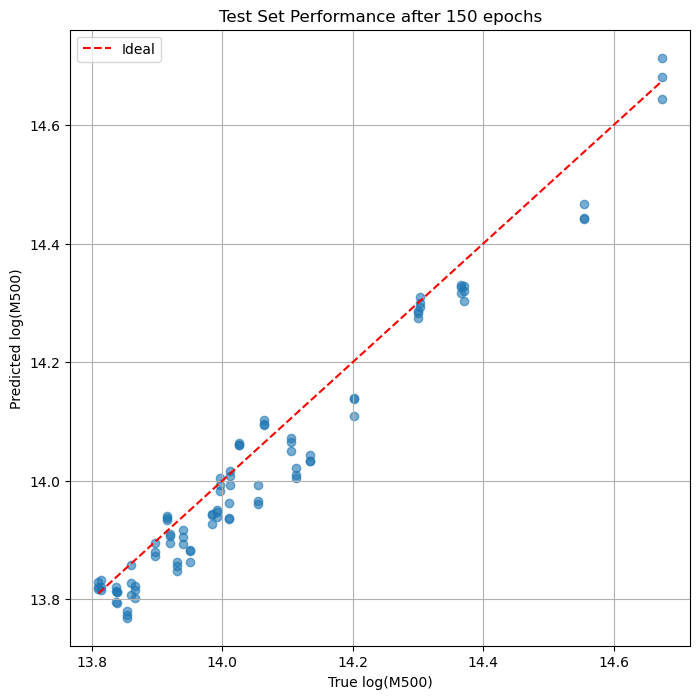

In [173]:
plt.figure(figsize=(8,8))
plt.scatter(true_values, predicted_values, alpha=0.6)
plt.plot([true_values.min(), true_values.max()],
         [true_values.min(), true_values.max()], 'r--', label='Ideal')
plt.xlabel('True log(M500)')
plt.ylabel('Predicted log(M500)')
plt.title(f'Test Set Performance after {epochs} epochs')
plt.legend()
plt.grid(True)
plt.show()

In [174]:
# ============================================
# SAVE FIRST RUN METRICS (NO ROTATION)
# ============================================
r2_no_rot = r2
mae_no_rot = mae
rmse_no_rot = rmse
scatter_no_rot = np.std(true_values - predicted_values)
bias_no_rot = np.mean(true_values - predicted_values)
true_no_rot = true_values.copy()
pred_no_rot = predicted_values.copy()

print("="*50)
print("✅ First run (no rotation) metrics saved.")
print("="*50)
print(f"R²: {r2_no_rot:.4f}")
print(f"Scatter: {scatter_no_rot:.4f} dex")
print(f"Bias: {bias_no_rot:.4f} dex")

✅ First run (no rotation) metrics saved.
R²: 0.9378
Scatter: 0.0400 dex
Bias: 0.0356 dex


Epoch 1/150


C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0227 - val_loss: 0.0501
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0076 - val_loss: 0.0308
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0060 - val_loss: 0.0295
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0061 - val_loss: 0.0245
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0076 - val_loss: 0.0249
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0055 - val_loss: 0.0225
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0057 - val_loss: 0.0174
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0055 - val_loss: 0.0191
Epoch 9/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0063 - val_loss: 0.0159
Epoch 10/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0067 - val_loss: 0.0089
Epoch 11/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0063 - val_loss: 0.0103
Epoch 12/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0

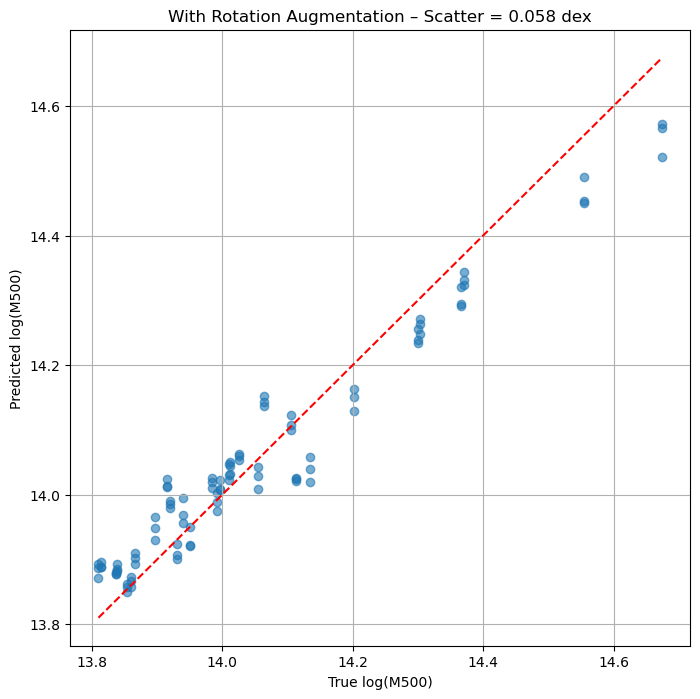

In [175]:
from keras import layers
import tensorflow as tf

# 1. Define augmentation
data_augmentation = keras.Sequential([
    layers.RandomRotation(factor=0.25),
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
])

# 2. Augmentation function
def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

# 3. Build training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)) \
    .shuffle(buffer_size=len(train_X)) \
    .map(augment_image, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_X, val_Y)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((test_X, test_Y)).batch(batch_size)

# 4. Rebuild model (or reuse if already defined)
# Make sure model is compiled
model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(learning_rate=0.0002))

# 5. Train
epochs = 150
hist = model.fit(train_dataset, validation_data=val_dataset, epochs=epochs, verbose=1)

# 6. Evaluate on test set
predictions = model.predict(test_X, batch_size=batch_size).flatten()
true_values = test_Y.flatten() + norm
predicted_values = predictions + norm

# Metrics
scatter = np.std(true_values - predicted_values)
bias = np.mean(true_values - predicted_values)
r2 = r2_score(true_values, predicted_values)
mae = mean_absolute_error(true_values, predicted_values)
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))

print("="*50)
print("AFTER ROTATION AUGMENTATION")
print("="*50)
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f} dex")
print(f"RMSE: {rmse:.4f} dex")
print(f"Scatter: {scatter:.4f} dex  ≈ {100*(10**scatter - 1):.1f}%")
print(f"Bias: {bias:.4f} dex")

# Plot true vs predicted
plt.figure(figsize=(8,8))
plt.scatter(true_values, predicted_values, alpha=0.6)
plt.plot([true_values.min(), true_values.max()],
         [true_values.min(), true_values.max()], 'r--')
plt.xlabel('True log(M500)')
plt.ylabel('Predicted log(M500)')
plt.title(f'With Rotation Augmentation – Scatter = {scatter:.3f} dex')
plt.grid(True)
plt.show()

In [178]:
# ============================================
# SAVE SECOND RUN METRICS (WITH ROTATION)
# ============================================
r2_rot = r2
mae_rot = mae
rmse_rot = rmse
scatter_rot = np.std(true_values - predicted_values)
bias_rot = np.mean(true_values - predicted_values)
true_rot = true_values.copy()
pred_rot = predicted_values.copy()

print("="*50)
print("✅ Second run (with rotation) metrics saved.")
print("="*50)
print(f"R²: {r2_rot:.4f}")
print(f"Scatter: {scatter_rot:.4f} dex")
print(f"Bias: {bias_rot:.4f} dex")

✅ Second run (with rotation) metrics saved.
R²: 0.9274
Scatter: 0.0578 dex
Bias: -0.0011 dex


FULL COMPARISON: NO ROTATION vs WITH ROTATION
               Metric  No Rotation  With Rotation  Δ (Rot - NoRot)
                   R²     0.937761       0.927446        -0.010315
            MAE (dex)     0.044137       0.048217         0.004080
           RMSE (dex)     0.053581       0.057850         0.004270
        Scatter (dex)     0.040020       0.057840         0.017820
     Mass Scatter (%)     9.652925      14.245785         4.592860
           Bias (dex)     0.035627      -0.001091        -0.036718
  Final Training Loss     0.003300       0.002400        -0.000900
Final Validation Loss     0.003600       0.006800         0.003200


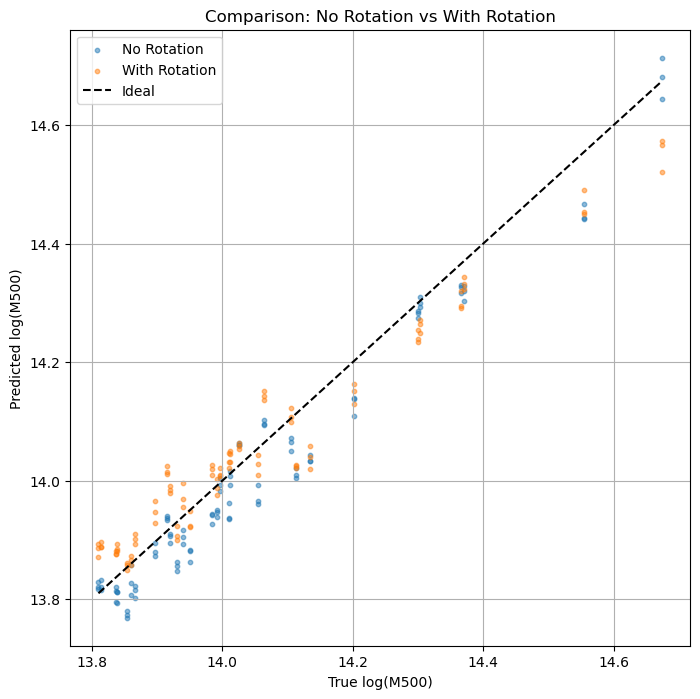

C:\Users\ulkar\AppData\Local\Temp\ipykernel_12892\2052633823.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([resid_no_rot, resid_rot], labels=['No Rotation', 'With Rotation'])


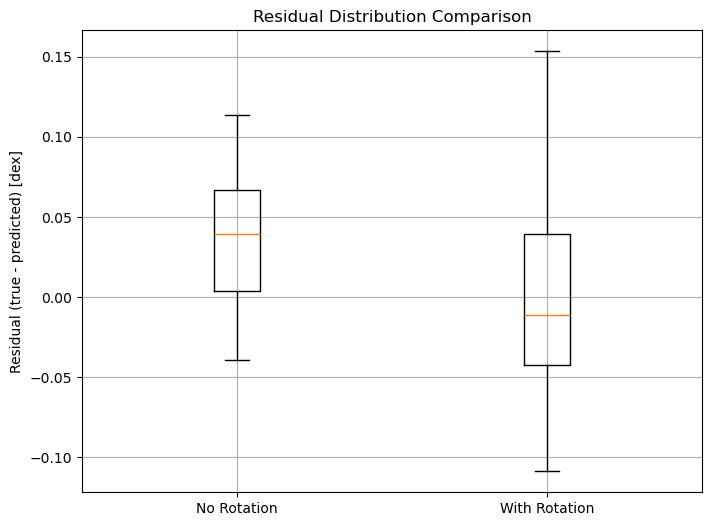

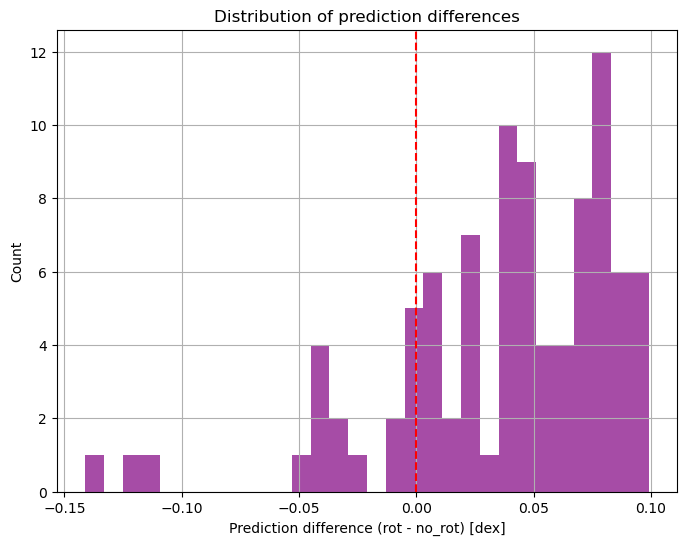

Mean difference: 0.0367 dex
Std of difference: 0.0480 dex


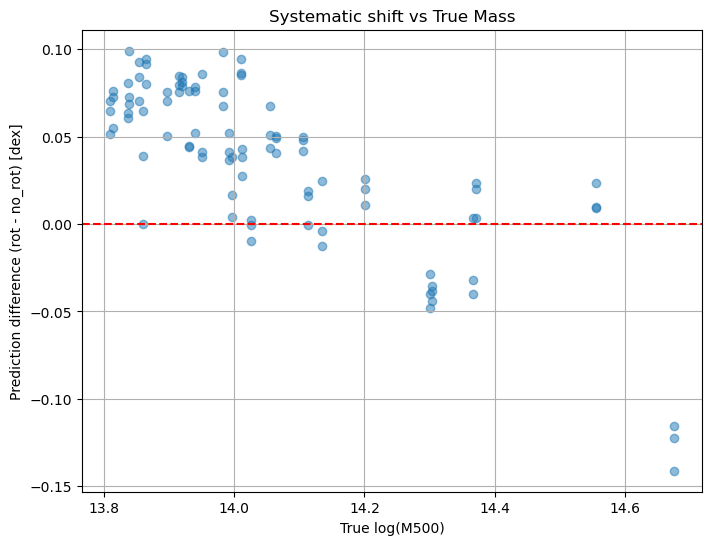

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# FULL COMPARISON TABLE (AUTOMATED)
# ============================================

# Mass scatter (%)
mass_scatter_no_rot = 100 * (10**scatter_no_rot - 1)
mass_scatter_rot   = 100 * (10**scatter_rot - 1)

# Validation losses – from your printed logs
# (You can replace these with variables if you stored them)
val_loss_no_rot = 0.0036   # from first run output
val_loss_rot   = 0.0068   # from second run output

# Training losses – from your printed logs
train_loss_no_rot = 0.0033
train_loss_rot   = 0.0024

comparison = pd.DataFrame({
    'Metric': [
        'R²',
        'MAE (dex)',
        'RMSE (dex)',
        'Scatter (dex)',
        'Mass Scatter (%)',
        'Bias (dex)',
        'Final Training Loss',
        'Final Validation Loss'
    ],
    'No Rotation': [
        r2_no_rot,
        mae_no_rot,
        rmse_no_rot,
        scatter_no_rot,
        mass_scatter_no_rot,
        bias_no_rot,
        train_loss_no_rot,
        val_loss_no_rot
    ],
    'With Rotation': [
        r2_rot,
        mae_rot,
        rmse_rot,
        scatter_rot,
        mass_scatter_rot,
        bias_rot,
        train_loss_rot,
        val_loss_rot
    ]
})

# Add difference column
comparison['Δ (Rot - NoRot)'] = comparison['With Rotation'] - comparison['No Rotation']

print("="*80)
print("FULL COMPARISON: NO ROTATION vs WITH ROTATION")
print("="*80)
print(comparison.to_string(index=False))

# ============================================
# VISUAL COMPARISON
# ============================================

# 1. Overlay scatter plots
plt.figure(figsize=(8,8))
plt.scatter(true_no_rot, pred_no_rot, alpha=0.5, s=10, label='No Rotation', c='C0')
plt.scatter(true_rot, pred_rot, alpha=0.5, s=10, label='With Rotation', c='C1')
plt.plot([true_no_rot.min(), true_no_rot.max()],
         [true_no_rot.min(), true_no_rot.max()], 'k--', label='Ideal')
plt.xlabel('True log(M500)')
plt.ylabel('Predicted log(M500)')
plt.title('Comparison: No Rotation vs With Rotation')
plt.legend()
plt.grid(True)
plt.show()

# 2. Residual box plots
resid_no_rot = true_no_rot - pred_no_rot
resid_rot   = true_rot - pred_rot

plt.figure(figsize=(8,6))
plt.boxplot([resid_no_rot, resid_rot], labels=['No Rotation', 'With Rotation'])
plt.ylabel('Residual (true - predicted) [dex]')
plt.title('Residual Distribution Comparison')
plt.grid(True)
plt.show()

# 3. Histogram of prediction differences
diff_pred = pred_rot - pred_no_rot

plt.figure(figsize=(8,6))
plt.hist(diff_pred, bins=30, alpha=0.7, color='purple')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Prediction difference (rot - no_rot) [dex]')
plt.ylabel('Count')
plt.title('Distribution of prediction differences')
plt.grid(True)
plt.show()

print(f"Mean difference: {np.mean(diff_pred):.4f} dex")
print(f"Std of difference: {np.std(diff_pred):.4f} dex")

# 4. Prediction difference vs true mass
plt.figure(figsize=(8,6))
plt.scatter(true_no_rot, diff_pred, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True log(M500)')
plt.ylabel('Prediction difference (rot - no_rot) [dex]')
plt.title('Systematic shift vs True Mass')
plt.grid(True)
plt.show()

Running 5-fold CV WITHOUT rotation...

--- Fold 1/5 (rotation=False) ---


C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Fold 2/5 (rotation=False) ---


C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Fold 3/5 (rotation=False) ---


...

C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



--- Fold 5/5 (rotation=True) ---


C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\ulkar\miniconda3\envs\alita2026\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



--- NO ROTATION (CV) ---
  R²      : 0.6728 ± 0.2162
  MAE     : 0.0810 ± 0.0124 dex
  RMSE    : 0.1284 ± 0.0546 dex
  Scatter : 0.1201 ± 0.0594 dex
  Bias    : 0.0357 ± 0.0210 dex
  Val Loss: 0.0189 ± 0.0180

--- WITH ROTATION (CV) ---
  R²      : 0.3043 ± 0.4555
  MAE     : 0.1245 ± 0.0327 dex
  RMSE    : 0.1853 ± 0.0821 dex
  Scatter : 0.1649 ± 0.0817 dex
  Bias    : 0.0655 ± 0.0603 dex
  Val Loss: 0.0397 ± 0.0341


C:\Users\ulkar\AppData\Local\Temp\ipykernel_12892\4081048225.py:162: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['No Rotation', 'With Rotation'])


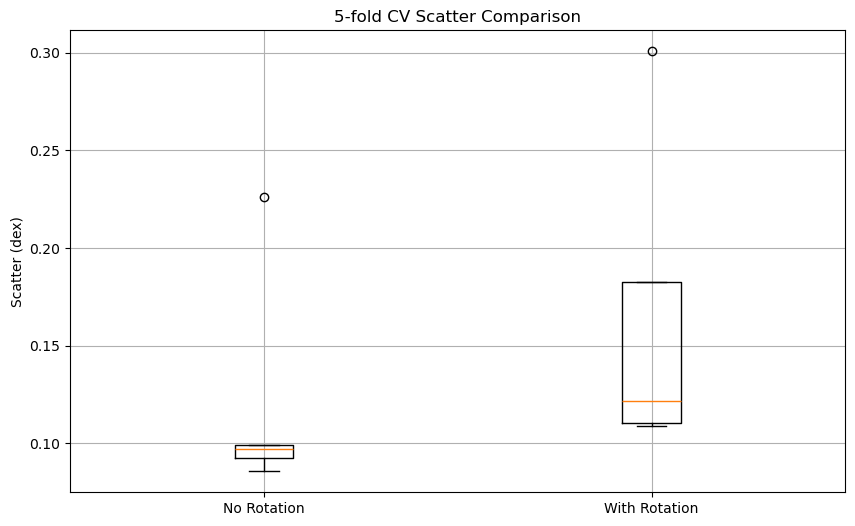

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D
import keras

# ============================================
# 1. CONFIGURATION
# ============================================
n_folds = 5
epochs = 50          # adjust as needed (100 for better results)
batch_size = 16

# Use the cluster list (excluding cluster 0, which is incomplete)
clusters = df['cluster_id'].unique()
clusters = clusters[clusters != 0]

# Build cluster -> indices mapping (already in cluster_to_indices)
cluster_indices = {cid: cluster_to_indices[cid] for cid in clusters}
cluster_masses = {cid: df[df['cluster_id'] == cid]['log_M500'].values[0] for cid in clusters}

# Normalize masses
norm_cv = np.nanmin(df['log_M500'])
for cid in cluster_masses:
    cluster_masses[cid] -= norm_cv

# ============================================
# 2. MODEL BUILDER
# ============================================
def build_model(input_shape=(140,140,1), with_augmentation=False):
    model = Sequential()
    model.add(Conv2D(16, (3,3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(32, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.1))
    model.add(Dense(200, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(loss='mean_squared_error',
                  optimizer=keras.optimizers.Adam(learning_rate=0.0002))
    return model

# ============================================
# 3. CROSS-VALIDATION FUNCTION
# ============================================
def run_cv(with_rotation=False):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(clusters)):
        print(f"\n--- Fold {fold+1}/{n_folds} (rotation={with_rotation}) ---")

        train_clusters = clusters[train_idx]
        val_clusters = clusters[val_idx]

        # Build training data
        train_indices = np.concatenate([cluster_indices[c] for c in train_clusters])
        train_X = images[train_indices].reshape(-1, 140, 140, 1)
        train_Y = np.array([cluster_masses[c] for c in train_clusters for _ in cluster_indices[c]])

        val_indices = np.concatenate([cluster_indices[c] for c in val_clusters])
        val_X = images[val_indices].reshape(-1, 140, 140, 1)
        val_Y = np.array([cluster_masses[c] for c in val_clusters for _ in cluster_indices[c]])

        # Build dataset with augmentation if requested
        if with_rotation:
            from keras import layers
            import tensorflow as tf
            data_augmentation = keras.Sequential([
                layers.RandomRotation(factor=0.25),
                layers.RandomFlip("horizontal"),
                layers.RandomFlip("vertical"),
            ])
            def augment_image(image, label):
                return data_augmentation(image, training=True), label

            train_dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)) \
                .shuffle(buffer_size=len(train_X)) \
                .map(augment_image, num_parallel_calls=tf.data.AUTOTUNE) \
                .batch(batch_size) \
                .prefetch(tf.data.AUTOTUNE)
            val_dataset = tf.data.Dataset.from_tensor_slices((val_X, val_Y)).batch(batch_size)

            model = build_model(with_augmentation=False)  # model architecture same
            hist = model.fit(train_dataset,
                             validation_data=val_dataset,
                             epochs=epochs,
                             verbose=0)
            # Predict on validation set (must use val_X, not dataset, to get predictions)
            pred_val = model.predict(val_X, verbose=0).flatten()
        else:
            model = build_model()
            hist = model.fit(train_X, train_Y,
                             validation_data=(val_X, val_Y),
                             batch_size=batch_size,
                             epochs=epochs,
                             verbose=0)
            pred_val = model.predict(val_X, verbose=0).flatten()

        # Metrics on validation set (normalized scale)
        r2 = r2_score(val_Y, pred_val)
        mae = mean_absolute_error(val_Y, pred_val)
        rmse = np.sqrt(mean_squared_error(val_Y, pred_val))
        scatter = np.std(val_Y - pred_val)
        bias = np.mean(val_Y - pred_val)

        fold_results.append({
            'fold': fold+1,
            'r2': r2,
            'mae': mae,
            'rmse': rmse,
            'scatter': scatter,
            'bias': bias,
            'val_loss': hist.history['val_loss'][-1]
        })

    # Convert to DataFrame
    df_cv = pd.DataFrame(fold_results)
    return df_cv

# ============================================
# 4. RUN CROSS-VALIDATION (both cases)
# ============================================
print("="*60)
print("Running 5-fold CV WITHOUT rotation...")
print("="*60)
cv_no_rot = run_cv(with_rotation=False)

print("\n" + "="*60)
print("Running 5-fold CV WITH rotation...")
print("="*60)
cv_rot = run_cv(with_rotation=True)

# ============================================
# 5. SUMMARISE RESULTS
# ============================================
def summarize_cv(df_cv, label):
    print(f"\n--- {label} ---")
    print(f"  R²      : {df_cv['r2'].mean():.4f} ± {df_cv['r2'].std():.4f}")
    print(f"  MAE     : {df_cv['mae'].mean():.4f} ± {df_cv['mae'].std():.4f} dex")
    print(f"  RMSE    : {df_cv['rmse'].mean():.4f} ± {df_cv['rmse'].std():.4f} dex")
    print(f"  Scatter : {df_cv['scatter'].mean():.4f} ± {df_cv['scatter'].std():.4f} dex")
    print(f"  Bias    : {df_cv['bias'].mean():.4f} ± {df_cv['bias'].std():.4f} dex")
    print(f"  Val Loss: {df_cv['val_loss'].mean():.4f} ± {df_cv['val_loss'].std():.4f}")

summarize_cv(cv_no_rot, "NO ROTATION (CV)")
summarize_cv(cv_rot, "WITH ROTATION (CV)")

# Optional: boxplot comparison
plt.figure(figsize=(10,6))
data_to_plot = [cv_no_rot['scatter'], cv_rot['scatter']]
plt.boxplot(data_to_plot, labels=['No Rotation', 'With Rotation'])
plt.ylabel('Scatter (dex)')
plt.title('5-fold CV Scatter Comparison')
plt.grid(True)
plt.show()

ROTATION EFFECT ON PREDICTED MASSES
Mean difference (rot - no_rot): 0.0367 dex
Std of difference: 0.0480 dex
Min difference: -0.1411 dex
Max difference: 0.0991 dex


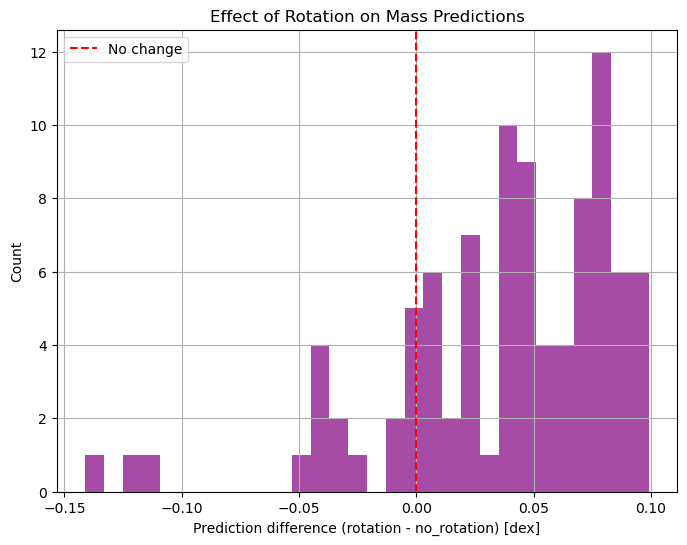

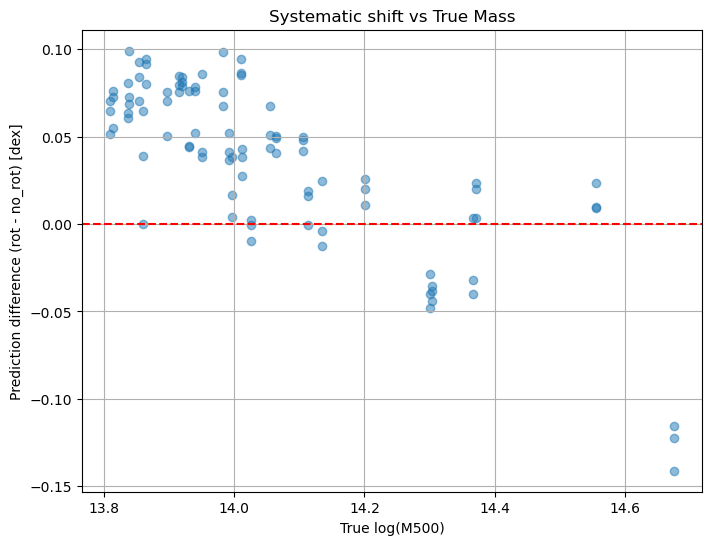

In [181]:
# Compare predictions on the same test set (from your saved variables)
diff = pred_rot - pred_no_rot   # rotation - no_rotation

print("="*50)
print("ROTATION EFFECT ON PREDICTED MASSES")
print("="*50)
print(f"Mean difference (rot - no_rot): {np.mean(diff):.4f} dex")
print(f"Std of difference: {np.std(diff):.4f} dex")
print(f"Min difference: {np.min(diff):.4f} dex")
print(f"Max difference: {np.max(diff):.4f} dex")

# Histogram of differences
plt.figure(figsize=(8,6))
plt.hist(diff, bins=30, alpha=0.7, color='purple')
plt.axvline(0, color='r', linestyle='--', label='No change')
plt.xlabel('Prediction difference (rotation - no_rotation) [dex]')
plt.ylabel('Count')
plt.title('Effect of Rotation on Mass Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Scatter plot of difference vs true mass
plt.figure(figsize=(8,6))
plt.scatter(true_no_rot, diff, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True log(M500)')
plt.ylabel('Prediction difference (rot - no_rot) [dex]')
plt.title('Systematic shift vs True Mass')
plt.grid(True)
plt.show()

[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/notebooks/master/assets/stsci_pri_combo_mark_horizonal_white_bkgd.png" alt="Space Telescope Logo" width="200px"/> 